# Taller 2: Predicción de Hipertensión Arterial
## MINE 4206 - Aprendizaje de Máquina (AML) - 2026-10

---

**Contexto del problema:** La hipertensión arterial es uno de los principales factores de riesgo de las enfermedades cardiovasculares, constituyendo una de las principales causas de morbilidad y mortalidad a nivel mundial. Su detección temprana representa un reto importante, ya que en muchos casos los síntomas pasan desapercibidos y el diagnóstico ocurre en etapas avanzadas.

**Objetivo:** Desarrollar y comparar distintos modelos de clasificación (Regresión Logística, SVC y Árboles de Decisión) que permitan estimar el riesgo de hipertensión a partir de variables demográficas, hábitos de vida y antecedentes médicos. Se priorizará el **Recall** como métrica principal dado el contexto clínico: es preferible detectar falsos positivos que dejar pasar casos reales de hipertensión.

## 0. Importación de Librerías

In [112]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

# Semilla global según indicaciones del taller
RANDOM_STATE = 77

print("Librerías importadas correctamente.")
print(f"Semilla configurada: {RANDOM_STATE}")

Librerías importadas correctamente.
Semilla configurada: 77


---
## 1. Exploración y Perfilamiento de los Datos

En esta sección se realiza un análisis exploratorio para comprender la estructura, calidad y características de los datos.

### 1.1 Carga de datos

In [172]:
# Cargar el dataset
df = pd.read_csv('Datos_hipertension.csv', encoding='cp1252', sep=';')

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas del dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

Dimensiones del dataset: 1990 filas x 13 columnas

Columnas del dataset:
  1. Edad
  2. Ingesta_Sal
  3. Nivel_Stres
  4. Colesterol
  5. Duración_Sueño
  6. BMI
  7. Medicación
  8. Historia_Familiar
  9. Actividad_Fisica
  10. Fumador
  11. Glucosa
  12. Enfermedad_Corazon
  13. Hipertension


In [114]:
# Visualizar las primeras filas
df.head(10)

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No
5,20,10.8,3,224.1,5.2,21.9,BloqueadorBeta,Si,Alta,No,135.0,No,Si
6,39,8.9,0,211.6,7.8,27.6,BloqueadorBeta,Si,Alta,No,106.3,No,No
7,70,5.9,1,249.2,7.2,25.8,Ninguna,No,Moderada,No,144.7,No,Si
8,19,9.3,7,218.3,4.7,36.5,BloqueadorBeta,Si,Baja,Si,132.7,Si,Si
9,47,7.2,5,190.9,6.2,24.3,Ninguna,No,Alta,No,100.3,No,No


### 1.2 Diccionario de datos

Según el archivo `Diccionario_Datos.xlsx`, las variables del dataset son:

| Variable | Descripción | Tipo |
|----------|-------------|------|
| Edad | Edad del individuo (en años) | Numérica |
| Ingesta_Sal | Consumo de sal en la dieta (escala numérica) | Numérica |
| Nivel_Stres | Nivel de estrés auto-reportado (escala 0-10) | Numérica |
| Colesterol | Nivel de colesterol total | Numérica |
| Duración_Sueño | Duración promedio del sueño por noche (en horas) | Numérica |
| BMI | Índice de masa corporal (IMC) | Numérica |
| Medicación | Tratamiento farmacológico (Ninguna/InhibidorACE/BloqueadorBeta/Diuretico/Otro) | Categórica |
| Historia_Familiar | Antecedentes familiares de hipertensión (Sí/No) | Categórica |
| Actividad_Fisica | Actividad física regular (Baja/Moderada/Alta) | Categórica ordinal |
| Fumador | Condición de fumador (Sí/No) | Categórica |
| Glucosa | Nivel de azúcar en sangre en ayunas | Numérica |
| Enfermedad_Corazon | Presencia de enfermedad cardiovascular (Sí/No) | Categórica |
| **Hipertension** | **Variable objetivo: Padecimiento de hipertensión (Sí/No)** | **Categórica** |

### 1.3 Estructura y tipos de datos

In [115]:
# Información general del dataset
print("=== Información del Dataset ===")
df.info()

=== Información del Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1990 entries, 0 to 1989
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                1990 non-null   int64  
 1   Ingesta_Sal         1990 non-null   float64
 2   Nivel_Stres         1990 non-null   int64  
 3   Colesterol          1990 non-null   float64
 4   Duración_Sueño      1990 non-null   float64
 5   BMI                 1990 non-null   float64
 6   Medicación          1990 non-null   object 
 7   Historia_Familiar   1990 non-null   object 
 8   Actividad_Fisica    1990 non-null   object 
 9   Fumador             1990 non-null   object 
 10  Glucosa             1990 non-null   float64
 11  Enfermedad_Corazon  1990 non-null   object 
 12  Hipertension        1990 non-null   object 
dtypes: float64(5), int64(2), object(6)
memory usage: 202.2+ KB


In [116]:
# Identificar tipos de variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Variables numéricas ({len(num_cols)}): {num_cols}")
print(f"\nVariables categóricas ({len(cat_cols)}): {cat_cols}")

Variables numéricas (7): ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI', 'Glucosa']

Variables categóricas (6): ['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador', 'Enfermedad_Corazon', 'Hipertension']


### 1.4 Análisis de valores faltantes

In [117]:
# Verificar valores nulos
print("=== Valores Faltantes ===")
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)

tabla_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': nulos_pct
})

print(tabla_nulos)
print(f"\nTotal de valores faltantes: {nulos.sum()}")

=== Valores Faltantes ===
                    Valores Nulos  Porcentaje (%)
Edad                            0             0.0
Ingesta_Sal                     0             0.0
Nivel_Stres                     0             0.0
Colesterol                      0             0.0
Duración_Sueño                  0             0.0
BMI                             0             0.0
Medicación                      0             0.0
Historia_Familiar               0             0.0
Actividad_Fisica                0             0.0
Fumador                         0             0.0
Glucosa                         0             0.0
Enfermedad_Corazon              0             0.0
Hipertension                    0             0.0

Total de valores faltantes: 0


**Observación:** El dataset no presenta valores faltantes, lo cual facilita el preprocesamiento.

### 1.5 Análisis de registros duplicados

In [118]:
# Verificar duplicados
duplicados = df.duplicated().sum()
print(f"=== Registros Duplicados ===")
print(f"Total de filas duplicadas: {duplicados}")
print(f"Porcentaje: {duplicados/len(df)*100:.2f}%")

if duplicados > 0:
    print(f"\nMostrando filas duplicadas:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

=== Registros Duplicados ===
Total de filas duplicadas: 4
Porcentaje: 0.20%

Mostrando filas duplicadas:


,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
1059,52,7.5,2,229.4,7.0,26.7,BloqueadorBeta,Si,Moderada,No,118.9,No,Si
1172,52,7.5,2,229.4,7.0,26.7,BloqueadorBeta,Si,Moderada,No,118.9,No,Si
1254,56,9.4,0,186.6,6.6,24.7,BloqueadorBeta,No,Baja,No,97.8,No,No
1346,56,9.4,0,186.6,6.6,24.7,BloqueadorBeta,No,Baja,No,97.8,No,No
919,66,5.8,9,183.7,6.6,25.8,Ninguna,No,Moderada,No,86.5,No,No
971,66,5.8,9,183.7,6.6,25.8,Ninguna,No,Moderada,No,86.5,No,No
146,79,10.8,0,249.5,6.7,24.8,Ninguna,Si,Baja,No,126.0,No,Si
167,79,10.8,0,249.5,6.7,24.8,Ninguna,Si,Baja,No,126.0,No,Si


**Observación:** Se detectaron 4 registros duplicados que deberán ser eliminados en la etapa de limpieza para evitar sesgos en el entrenamiento.

### 1.6 Estadísticas descriptivas de variables numéricas

In [119]:
# Estadísticas descriptivas
print("=== Estadísticas Descriptivas - Variables Numéricas ===")
df[num_cols].describe().T

=== Estadísticas Descriptivas - Variables Numéricas ===


,count,mean,std,min,25%,50%,75%,max
Edad,1990.0,50.379397,19.439669,18.0,34.000,50.0,67.000,84.0
Ingesta_Sal,1990.0,8.531608,1.994245,2.5,7.200,8.5,9.900,16.4
Nivel_Stres,1990.0,4.974372,3.144396,0.0,2.000,5.0,8.000,10.0
Colesterol,1990.0,209.526935,75.791456,121.2,181.325,204.4,231.700,2360.0
Duración_Sueño,1990.0,6.452613,1.540354,1.5,5.400,6.5,7.500,11.4
BMI,1990.0,26.013869,4.507425,11.9,23.000,25.9,29.100,41.9
Glucosa,1990.0,105.642211,22.541122,70.0,89.200,102.5,119.875,196.1


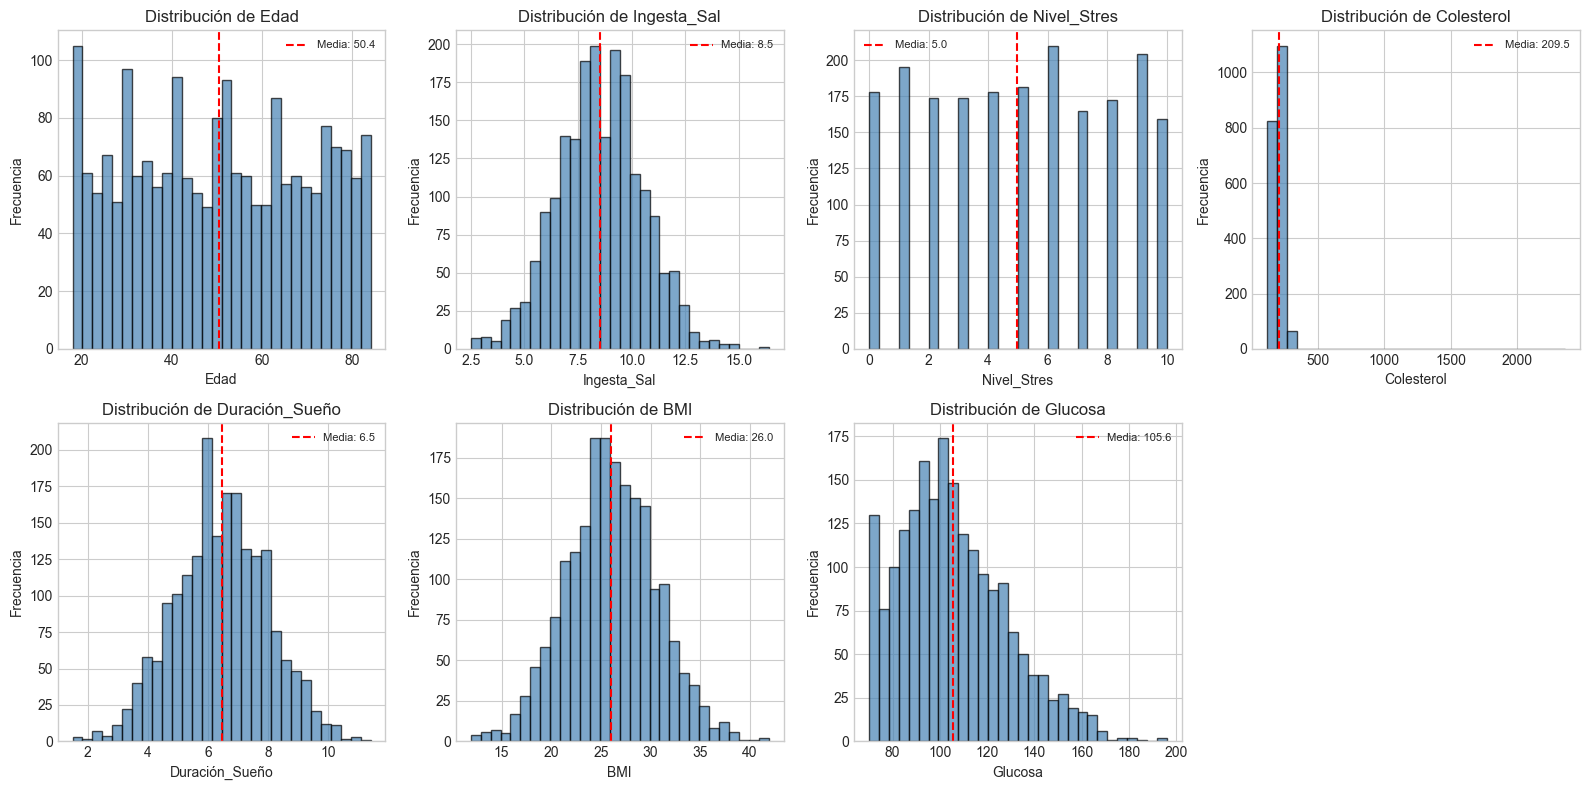

In [120]:
# Visualización de distribuciones numéricas
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i < len(axes):
        axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')
        # Añadir línea de media
        axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Media: {df[col].mean():.1f}')
        axes[i].legend(fontsize=8)

# Ocultar subplot vacío si hay menos de 8 variables
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Observaciones sobre variables numéricas:**

- **Edad:** Distribución relativamente uniforme entre 18 y 84 años, media de 50 años
- **Ingesta_Sal:** Media de 8.5, rango de 2.5 a 16.4
- **Nivel_Stres:** Escala de 0-10, distribución uniforme
- **Colesterol:** Media de 209, pero con valores máximos sospechosos (hasta 2360)
- **Duración_Sueño:** Media de 6.5 horas, rango de 1.5 a 11.4 horas
- **BMI:** Media de 26, rango de 11.9 a 41.9
- **Glucosa:** Media de 105, rango de 70 a 196

### 1.7 Detección de valores atípicos en Colesterol

In [121]:
# Análisis específico de Colesterol
print("=== Análisis de Colesterol ===")
print(f"Estadísticas básicas:")
print(df['Colesterol'].describe())

print(f"\nValores más altos:")
print(df['Colesterol'].nlargest(10).values)

# Identificar valores anómalos (> 400 mg/dL es extremadamente alto)
valores_anomalos = df[df['Colesterol'] > 400]['Colesterol']
print(f"\nValores > 400 mg/dL (sospechosos): {valores_anomalos.values}")
print(f"Cantidad de valores anómalos: {len(valores_anomalos)}")

=== Análisis de Colesterol ===
Estadísticas básicas:
count    1990.000000
mean      209.526935
std        75.791456
min       121.200000
25%       181.325000
50%       204.400000
75%       231.700000
max      2360.000000
Name: Colesterol, dtype: float64

Valores más altos:
[2360.  1835.  1597.   326.3  307.   298.   296.1  295.8  295.   294.5]

Valores > 400 mg/dL (sospechosos): [2360. 1597. 1835.]
Cantidad de valores anómalos: 3


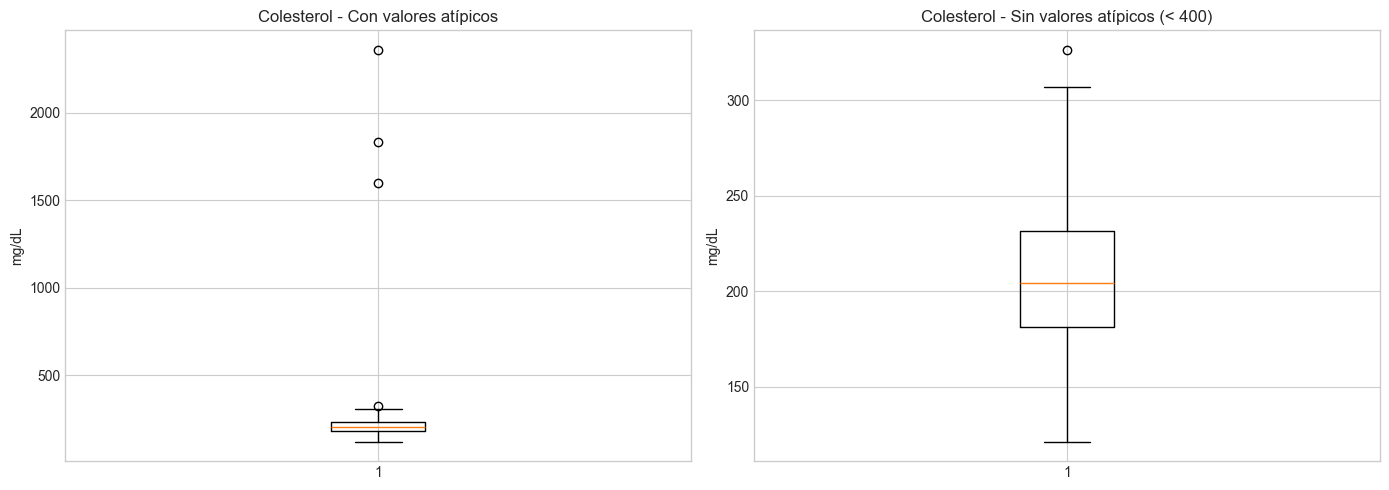

In [122]:
# Boxplot de Colesterol
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot con outliers
axes[0].boxplot(df['Colesterol'])
axes[0].set_title('Colesterol - Con valores atípicos')
axes[0].set_ylabel('mg/dL')

# Boxplot sin outliers extremos (< 400)
axes[1].boxplot(df[df['Colesterol'] < 400]['Colesterol'])
axes[1].set_title('Colesterol - Sin valores atípicos (< 400)')
axes[1].set_ylabel('mg/dL')

plt.tight_layout()
plt.show()

**Análisis de valores atípicos en Colesterol:**

Se identificaron 3 valores extremadamente altos: **2360, 1835, y 1597 mg/dL**. Estos valores se encuentran muy alejados del rango intercuartílico (Q1=181, Q3=232) y de la media (209 mg/dL)..

**Hipótesis:** Estos valores parecen ser errores de tipeo donde el punto decimal fue omitido:
- 2360 → probablemente debería ser **236.0**
- 1835 → probablemente debería ser **183.5**
- 1597 → probablemente debería ser **159.7**

**Decisión:** Dividir por 10 los valores de Colesterol mayores a 400 mg/dL.

### 1.8 Análisis de variables categóricas

In [123]:
# Distribución de variables categóricas
print("=== Distribución de Variables Categóricas ===")
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(f"Valores únicos: {df[col].nunique()}")

=== Distribución de Variables Categóricas ===

--- Medicación ---
Medicación
Ninguna           802
BloqueadorBeta    414
InhibidorACE      323
Diuretico         245
Otro              206
Name: count, dtype: int64
Valores únicos: 5

--- Historia_Familiar ---
Historia_Familiar
No    1003
Si     987
Name: count, dtype: int64
Valores únicos: 2

--- Actividad_Fisica ---
Actividad_Fisica
Baja        938
Moderada    660
Alta        392
Name: count, dtype: int64
Valores únicos: 3

--- Fumador ---
Fumador
No    1422
Si     568
Name: count, dtype: int64
Valores únicos: 2

--- Enfermedad_Corazon ---
Enfermedad_Corazon
No    1515
Si     475
Name: count, dtype: int64
Valores únicos: 2

--- Hipertension ---
Hipertension
Si    1034
No     956
Name: count, dtype: int64
Valores únicos: 2


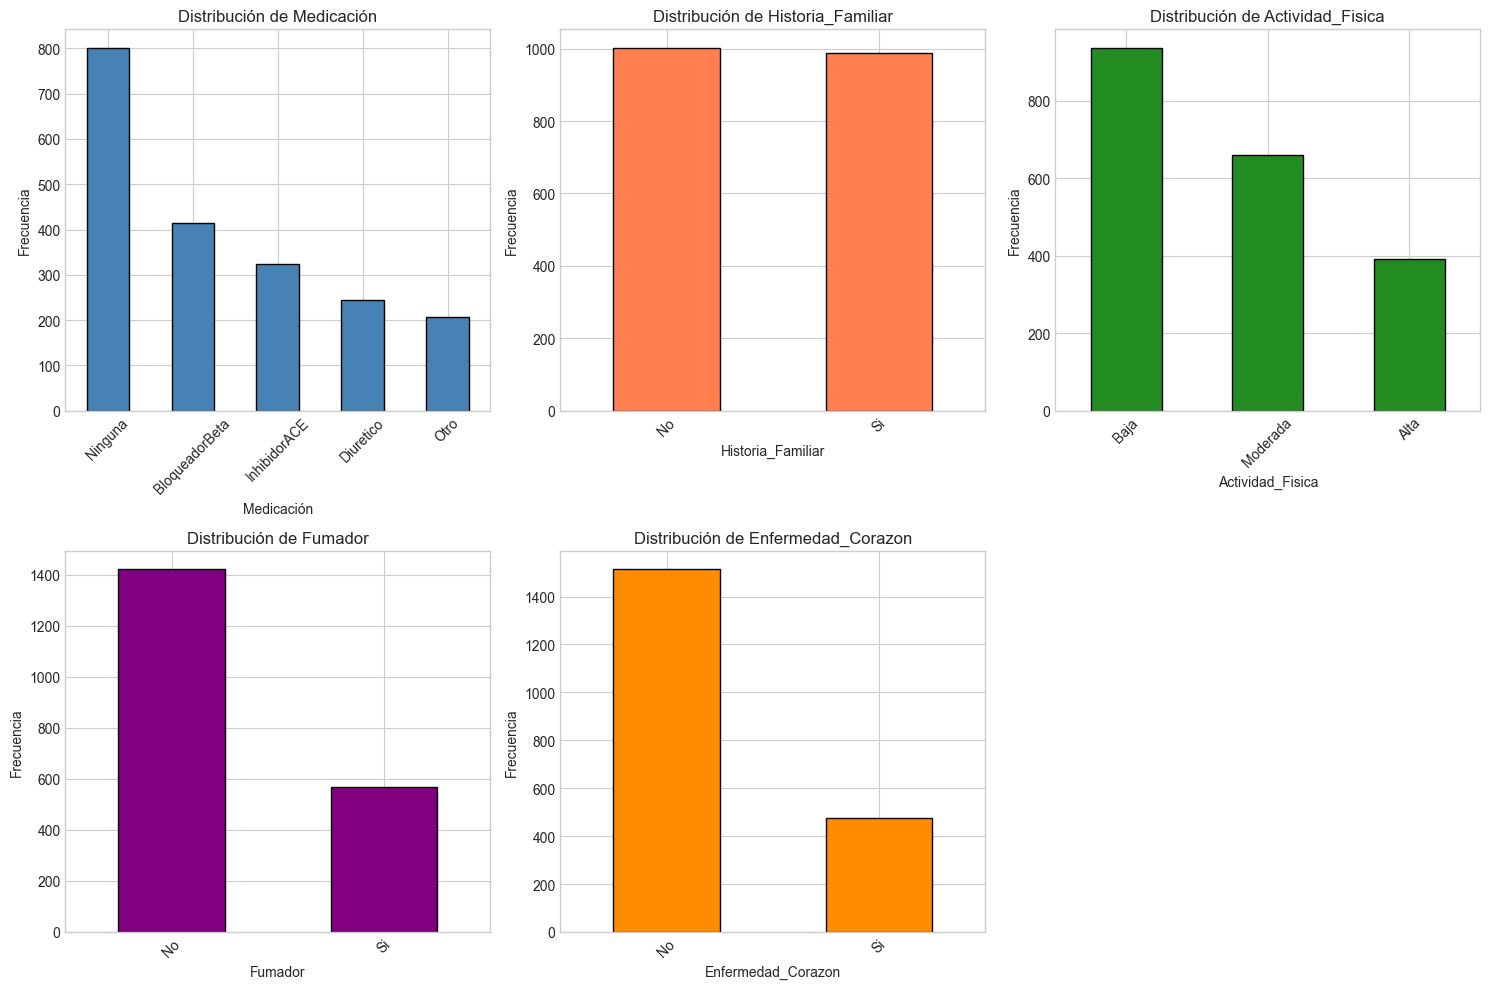

In [124]:
# Visualización de variables categóricas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

cat_cols_sin_target = [col for col in cat_cols if col != 'Hipertension']

colors = ['steelblue', 'coral', 'forestgreen', 'purple', 'darkorange', 'teal']

for i, col in enumerate(cat_cols_sin_target):
    if i < len(axes):
        df[col].value_counts().plot(kind='bar', ax=axes[i], color=colors[i % len(colors)], edgecolor='black')
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_ylabel('Frecuencia')
        axes[i].tick_params(axis='x', rotation=45)

# Ocultar subplots vacíos
for j in range(len(cat_cols_sin_target), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Observaciones sobre variables categóricas:**

- **Medicación:** La mayoría no toma medicación ("Ninguna"), seguido de tratamientos específicos
- **Historia_Familiar:** Distribución relativamente balanceada entre Sí y No
- **Actividad_Fisica:** Tres niveles (Baja, Moderada, Alta). La categoría 'Baja' es la más frecuente, seguida de 'Moderada' y 'Alta'.
- **Fumador:** Mayoría no fumadores
- **Enfermedad_Corazon:** Mayoría sin enfermedad cardiovascular previa

### 1.9 Análisis de la variable objetivo

In [125]:
# Distribución de la variable objetivo
print("=== Variable Objetivo: Hipertension ===")
print(df['Hipertension'].value_counts())
print(f"\nProporción:")
print(df['Hipertension'].value_counts(normalize=True).round(4))

=== Variable Objetivo: Hipertension ===
Hipertension
Si    1034
No     956
Name: count, dtype: int64

Proporción:
Hipertension
Si    0.5196
No    0.4804
Name: proportion, dtype: float64


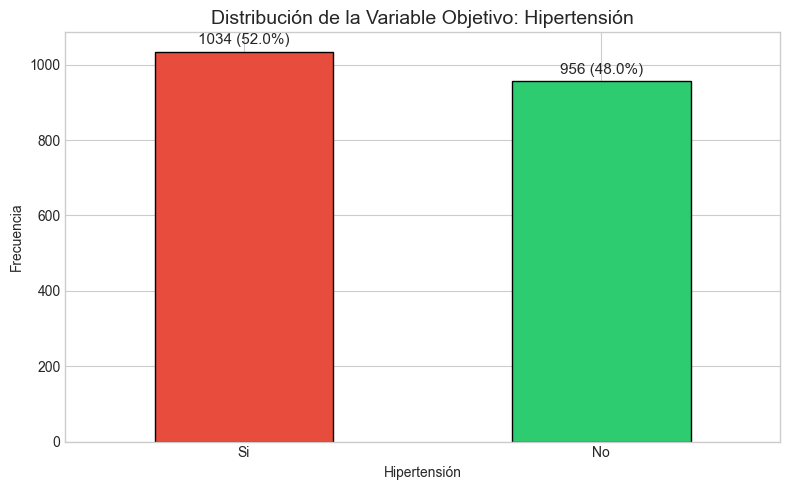

In [126]:
# Visualización del balance de clases
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#e74c3c', '#2ecc71']  # Rojo para Sí, Verde para No
df['Hipertension'].value_counts().plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Distribución de la Variable Objetivo: Hipertensión', fontsize=14)
ax.set_xlabel('Hipertensión')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=0)

# Añadir etiquetas de porcentaje
for i, (idx, val) in enumerate(df['Hipertension'].value_counts().items()):
    ax.text(i, val + 20, f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

**Observación:** Las clases están relativamente balanceadas (52% Sí vs 48% No), lo cual es favorable para el entrenamiento de los modelos. No será necesario aplicar técnicas de balanceo como SMOTE o undersampling.

### 1.10 Análisis de correlaciones

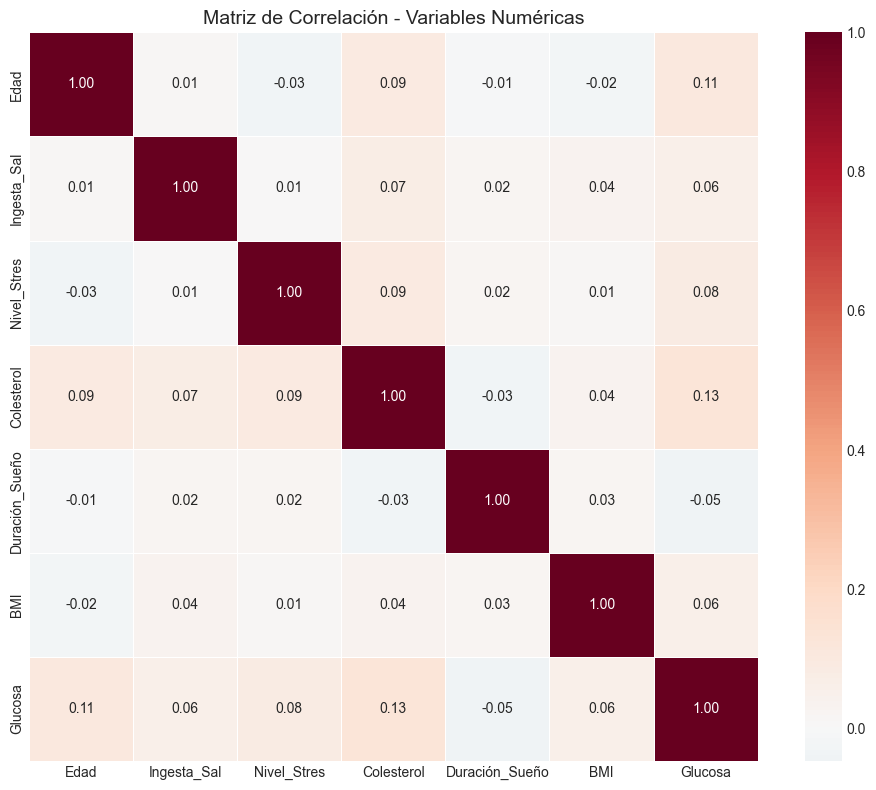

In [127]:
# Matriz de correlación para variables numéricas
fig, ax = plt.subplots(figsize=(10, 8))

correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación - Variables Numéricas', fontsize=14)

plt.tight_layout()
plt.show()

In [128]:
# Correlaciones más fuertes
print("=== Correlaciones Significativas (|r| > 0.3) ===")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:
            print(f"{correlation_matrix.columns[i]} vs {correlation_matrix.columns[j]}: {corr_val:.3f}")

=== Correlaciones Significativas (|r| > 0.3) ===


**Observaciones sobre correlaciones:**

- No se observan correlaciones fuertes entre las variables numéricas (todas |r| < 0.3)
- Esto sugiere que las variables aportan información independiente al modelo
- No hay problemas evidentes de multicolinealidad

### 1.11 Relación entre variables y la variable objetivo

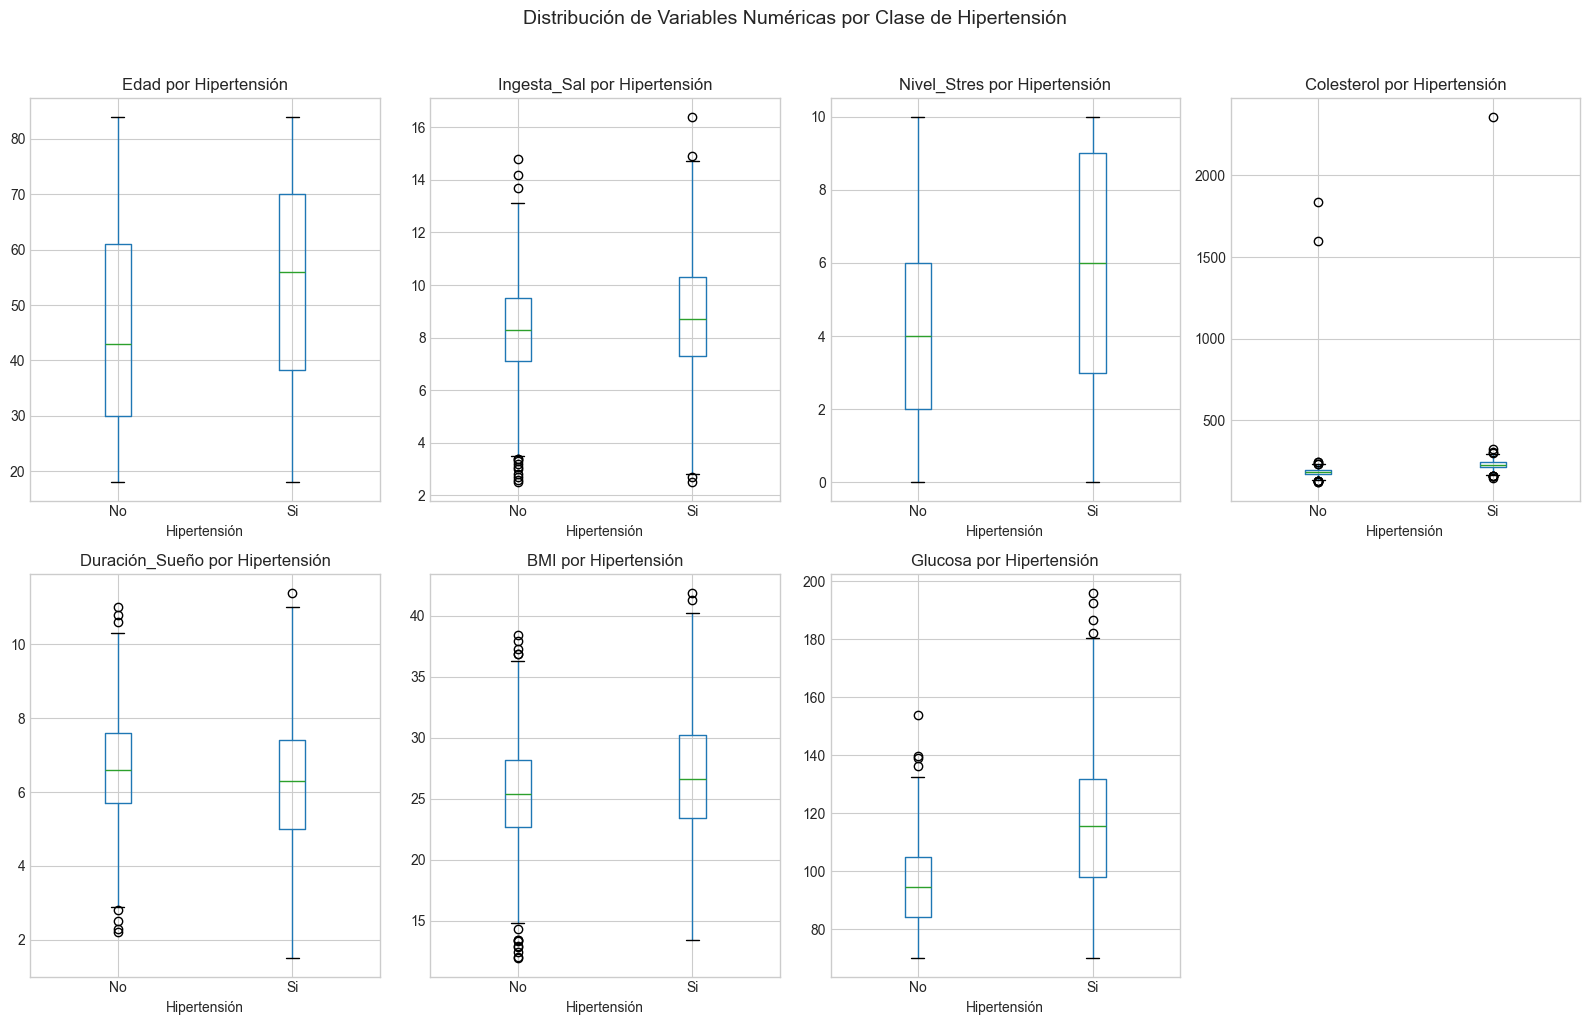

In [129]:
# Comparación de variables numéricas por clase de hipertensión
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i < len(axes):
        df.boxplot(column=col, by='Hipertension', ax=axes[i])
        axes[i].set_title(f'{col} por Hipertensión')
        axes[i].set_xlabel('Hipertensión')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas por Clase de Hipertensión', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [130]:
# Estadísticas por grupo
print("=== Media de Variables Numéricas por Clase ===")
print(df.groupby('Hipertension')[num_cols].mean().T.round(2))

=== Media de Variables Numéricas por Clase ===
Hipertension        No      Si
Edad             46.14   54.30
Ingesta_Sal       8.29    8.75
Nivel_Stres       4.37    5.53
Colesterol      184.49  232.68
Duración_Sueño    6.64    6.28
BMI              25.33   26.64
Glucosa          95.17  115.32


### 1.12 Resumen del perfilamiento

**Hallazgos principales:**

1. **Calidad de datos:**
   - Sin valores faltantes
   - 4 registros duplicados que deben eliminarse
   - 3 valores anómalos en Colesterol (2360, 1835, 1597) que parecen errores de tipeo

2. **Variables numéricas (7):**
   - Edad, Ingesta_Sal, Nivel_Stres, Colesterol, Duración_Sueño, BMI, Glucosa
   - No hay multicolinealidad significativa
   - Escalas diferentes → requerirán normalización/estandarización

3. **Variables categóricas (5 predictoras + 1 objetivo):**
   - Medicación (5 categorías), Historia_Familiar, Actividad_Fisica (ordinal), Fumador, Enfermedad_Corazon
   - Requerirán codificación (OneHotEncoder u OrdinalEncoder)

4. **Variable objetivo:**
   - Hipertension (Sí/No) - clases balanceadas (52% vs 48%)

5. **Acciones de limpieza necesarias:**
   - Eliminar 4 registros duplicados
   - Corregir valores de Colesterol > 400 (dividir por 10)

---
## 2. Limpieza y Preparación de los Datos

Con base en el análisis exploratorio, se realizan las siguientes acciones de limpieza y preparación.

### 2.1 Copia del dataset original

In [131]:
# Crear copia para trabajar
df_clean = df.copy()
print(f"Registros iniciales: {len(df_clean)}")

Registros iniciales: 1990


### 2.2 Eliminación de registros duplicados

**Decisión:** Eliminar los registros duplicados para evitar:
- Sesgo en el entrenamiento (el modelo vería los mismos patrones múltiples veces)
- Posible fuga de datos si un duplicado queda en train y otro en test

In [132]:
# Eliminar duplicados
registros_antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
registros_despues = len(df_clean)

print(f"Registros antes: {registros_antes}")
print(f"Registros después: {registros_despues}")
print(f"Registros eliminados: {registros_antes - registros_despues}")

# Verificar
print(f"\nVerificación - Duplicados restantes: {df_clean.duplicated().sum()}")

Registros antes: 1990
Registros después: 1986
Registros eliminados: 4

Verificación - Duplicados restantes: 0


### 2.3 Corrección de valores anómalos en Colesterol

**Decisión:** Dividir por 10 los valores de Colesterol mayores a 400 mg/dL, ya que:
- Son datos atipicos (colesterol > 400 es raro)
- El patrón sugiere error de tipeo (punto decimal omitido)
- Los valores corregidos (236.0, 183.5, 159.7) están dentro del rango normal

In [133]:
# Mostrar valores antes de corregir
print("=== Valores de Colesterol > 400 (antes de corregir) ===")
print(df_clean[df_clean['Colesterol'] > 400]['Colesterol'].values)

# Corregir valores anómalos
df_clean.loc[df_clean['Colesterol'] > 400, 'Colesterol'] = df_clean.loc[df_clean['Colesterol'] > 400, 'Colesterol'] / 10

# Verificar corrección
print("\n=== Verificación después de corregir ===")
print(f"Valor máximo de Colesterol: {df_clean['Colesterol'].max():.1f}")
print(f"Valores > 400: {len(df_clean[df_clean['Colesterol'] > 400])}")

print("\n=== Nuevas estadísticas de Colesterol ===")
print(df_clean['Colesterol'].describe())

=== Valores de Colesterol > 400 (antes de corregir) ===
[2360. 1597. 1835.]

=== Verificación después de corregir ===
Valor máximo de Colesterol: 326.3
Valores > 400: 0

=== Nuevas estadísticas de Colesterol ===
count    1986.000000
mean      206.896576
std        33.447263
min       121.200000
25%       181.225000
50%       204.200000
75%       231.700000
max       326.300000
Name: Colesterol, dtype: float64


### 2.4 Definición de variables

In [134]:
# Definir variable objetivo
target = 'Hipertension'

# Convertir a valores numéricos (1 = Si, 0 = No)
df_clean[target] = df_clean[target].map({'Si': 1, 'No': 0})

# Definir features numéricas
num_features = ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 
                'Duración_Sueño', 'BMI', 'Glucosa']

# Definir features categóricas
cat_features = ['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 
                'Fumador', 'Enfermedad_Corazon']

print(f"Variable objetivo: {target}")
print(f"\nFeatures numéricas ({len(num_features)}): {num_features}")
print(f"\nFeatures categóricas ({len(cat_features)}): {cat_features}")
print(f"\nTotal de features: {len(num_features) + len(cat_features)}")

Variable objetivo: Hipertension

Features numéricas (7): ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI', 'Glucosa']

Features categóricas (5): ['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador', 'Enfermedad_Corazon']

Total de features: 12


### 2.5 División train-test

**Decisión:** 
- Proporción 80% entrenamiento / 20% prueba
- Usar `stratify` para mantener la proporción de clases en ambos conjuntos
- Semilla `random_state=77` según indicaciones del taller

In [135]:
# Separar features y target
X = df_clean[num_features + cat_features]
y = df_clean[target]

# División train-test con stratify para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y  # Mantiene la proporción de clases en train y test
)

print(f"Tamaño conjunto de entrenamiento: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Tamaño conjunto de prueba: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\n=== Verificación de Stratify ===")
print(f"Proporción en y original: {y.value_counts(normalize=True).round(4).to_dict()}")
print(f"Proporción en y_train:    {y_train.value_counts(normalize=True).round(4).to_dict()}")
print(f"Proporción en y_test:     {y_test.value_counts(normalize=True).round(4).to_dict()}")

Tamaño conjunto de entrenamiento: 1588 (80.0%)
Tamaño conjunto de prueba: 398 (20.0%)

=== Verificación de Stratify ===
Proporción en y original: {1: 0.5196, 0: 0.4804}
Proporción en y_train:    {1: 0.5195, 0: 0.4805}
Proporción en y_test:     {1: 0.5201, 0: 0.4799}


**¿Por qué usamos `stratify`?**

El parámetro `stratify=y` asegura que la proporción de clases (Sí/No) sea la misma en los conjuntos de entrenamiento y prueba. Esto es importante en clasificación para:
1. Evitar que por azar un conjunto quede desbalanceado
2. Obtener métricas de evaluación representativas
3. Garantizar que el modelo vea ambas clases durante el entrenamiento

---
## 3. Pipeline con Regresión Logística y SVC

En esta sección se implementa un pipeline que integre:
- Preprocesamiento (escaladores para numéricas, encoders para categóricas)
- Modelos: Regresión Logística y SVC
- Búsqueda de hiperparámetros con GridSearchCV optimizando **Recall**

### 3.1 Justificación de la métrica: ¿Por qué Recall?

En el contexto clínico de detección de hipertensión:

| Métrica | Fórmula | Significado clínico |
|---------|---------|---------------------|
| **Recall (Sensibilidad)** | TP / (TP + FN) | % de enfermos correctamente detectados |
| Precision | TP / (TP + FP) | % de predicciones positivas que son correctas |

**¿Por qué priorizar Recall?**

- Un **falso negativo** (FN) significa no detectar a un paciente con hipertensión → puede llevar a complicaciones graves
- Un **falso positivo** (FP) significa alarmar innecesariamente a un paciente sano → genera más exámenes pero no daño directo

En medicina preventiva, **es preferible tener más falsos positivos que dejar pasar casos reales**.

### 3.2 Construcción del Pipeline con GridSearchCV

In [ ]:
# Definir transformadores para preprocesamiento
# Nota: Se esa 'passthrough' como opción para probar sin escalado

# Transformador para variables numéricas (a explorar: StandardScaler, MinMaxScaler)
numeric_transformer_standard = Pipeline(steps=[
    ('scaler', StandardScaler())
])

numeric_transformer_minmax = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

# Transformador para variables categóricas (a explorar: OneHotEncoder, OrdinalEncoder)
categorical_transformer_onehot = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

categorical_transformer_ordinal = Pipeline(steps=[
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

print("Transformadores definidos correctamente.")

Transformadores definidos correctamente.


In [ ]:
# Crear el ColumnTransformer base (usando StandardScaler y OneHotEncoder como base)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

# Pipeline completo con clasificador placeholder
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

print("Pipeline base configurado correctamente.")

Pipeline base configurado correctamente.


In [ ]:
# Definir la grilla de hiperparámetros
# Explorar: escaladores, encoders, modelos y sus hiperparámetros

param_grid = [
    # Regresión Logística con diferentes preprocesadores
    {
        'preprocessor__num': [StandardScaler(), MinMaxScaler()],
        'preprocessor__cat': [
            OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        ],
        'classifier': [LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1, 10, 100]
    },
    # SVC con diferentes preprocesadores
    {
        'preprocessor__num': [StandardScaler(), MinMaxScaler()],
        'preprocessor__cat': [
            OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        ],
        'classifier': [SVC(random_state=RANDOM_STATE)],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__kernel': ['rbf', 'linear']
    }
]

print("Grilla de hiperparámetros definida.")
print(f"\nCombinaciones aproximadas a evaluar:")
print(f"  - Logistic Regression: 2 scalers × 2 encoders × 5 C = 20")
print(f"  - SVC: 2 scalers × 2 encoders × 5 C × 2 kernels = 40")
print(f"  - Total: ~60 combinaciones × 5 folds = ~300 ajustes")

Grilla de hiperparámetros definida.

Combinaciones aproximadas a evaluar:
  - Logistic Regression: 2 scalers × 2 encoders × 5 C = 20
  - SVC: 2 scalers × 2 encoders × 5 C × 2 kernels = 40
  - Total: ~60 combinaciones × 5 folds = ~300 ajustes


In [139]:
# Configurar GridSearchCV
# Métrica: Recall (para la clase positiva 'Si')
# Validación cruzada estratificada con 5 folds

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',  # Optimizar para Recall
    cv=cv,
    n_jobs=-1,  # Usar todos los cores disponibles
    verbose=1,
    return_train_score=True
)

print("GridSearchCV configurado.")
print(f"  - Métrica de optimización: Recall")
print(f"  - Validación cruzada: 5 folds estratificados")
print(f"  - Semilla: {RANDOM_STATE}")

GridSearchCV configurado.
  - Métrica de optimización: Recall
  - Validación cruzada: 5 folds estratificados
  - Semilla: 77


In [140]:
# Ejecutar la búsqueda de hiperparámetros
print("Iniciando búsqueda de hiperparámetros...")
print("Esto puede tomar unos minutos...\n")

grid_search.fit(X_train, y_train)

print("\n✓ Búsqueda completada.")

Iniciando búsqueda de hiperparámetros...
Esto puede tomar unos minutos...

Fitting 5 folds for each of 60 candidates, totalling 300 fits

✓ Búsqueda completada.


### 3.3 Resultados de la búsqueda de hiperparámetros

In [141]:
# Mejor modelo y parámetros
print("=== Mejor Modelo Encontrado ===")
print(f"\nMejor score de Recall (CV): {grid_search.best_score_:.4f}")
print(f"\nMejores parámetros:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

=== Mejor Modelo Encontrado ===

Mejor score de Recall (CV): 1.0000

Mejores parámetros:
  - classifier: SVC(random_state=77)
  - classifier__C: 0.01
  - classifier__kernel: rbf
  - preprocessor__cat: OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
  - preprocessor__num: MinMaxScaler()


In [142]:
# Top 10 mejores configuraciones
print("=== Top 10 Configuraciones (por Recall) ===")

results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

# Seleccionar columnas relevantes
cols_mostrar = ['rank_test_score', 'mean_test_score', 'std_test_score', 
                'mean_train_score', 'param_classifier', 'param_classifier__C']

# Filtrar columnas que existen
cols_existentes = [col for col in cols_mostrar if col in results_df.columns]

print(results_df[cols_existentes].head(10).to_string(index=False))

=== Top 10 Configuraciones (por Recall) ===
 rank_test_score  mean_test_score  std_test_score  mean_train_score                                   param_classifier  param_classifier__C
               1         1.000000        0.000000          1.000000                               SVC(random_state=77)                 0.01
               1         1.000000        0.000000          0.999091                               SVC(random_state=77)                 0.01
               3         0.978182        0.006181          0.978485                               SVC(random_state=77)                 0.01
               4         0.962424        0.011752          0.964848                               SVC(random_state=77)                 0.01
               5         0.912727        0.010567          0.916667 LogisticRegression(max_iter=1000, random_state=77)                10.00
               5         0.912727        0.006181          0.920606 LogisticRegression(max_iter=1000, random_state=7

In [143]:
# Guardar el mejor modelo
best_model_lr_svc = grid_search.best_estimator_
print(f"Mejor modelo guardado: {type(best_model_lr_svc.named_steps['classifier']).__name__}")

Mejor modelo guardado: SVC


### 3.4 Evaluación del mejor modelo en conjunto de prueba

In [144]:
# Predicciones en test
y_pred_lr_svc = best_model_lr_svc.predict(X_test)

# Métricas
print("=== Rendimiento en Conjunto de Test ===")
print(f"\nModelo: {type(best_model_lr_svc.named_steps['classifier']).__name__}")
print(f"\n{classification_report(y_test, y_pred_lr_svc)}")

=== Rendimiento en Conjunto de Test ===

Modelo: SVC

              precision    recall  f1-score   support

           0       0.98      0.23      0.37       191
           1       0.58      1.00      0.73       207

    accuracy                           0.63       398
   macro avg       0.78      0.61      0.55       398
weighted avg       0.77      0.63      0.56       398



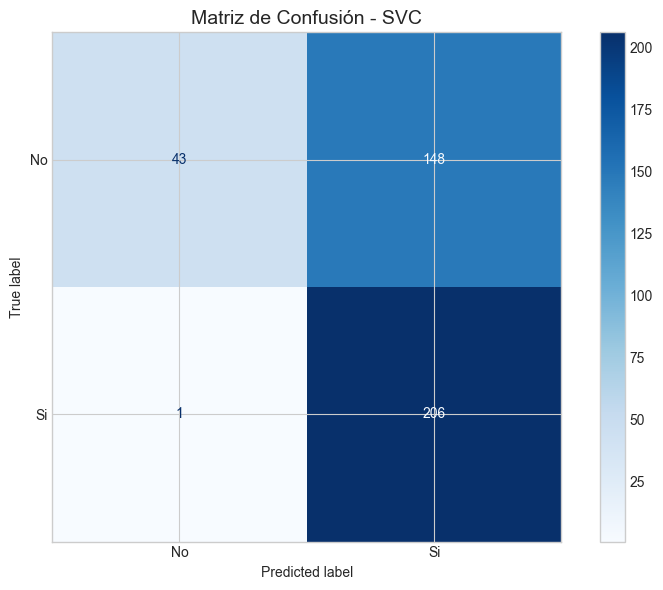


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 43 - Pacientes SIN hipertensión correctamente clasificados
  - Falsos Positivos (FP): 148 - Pacientes sanos clasificados erróneamente como enfermos
  - Falsos Negativos (FN): 1 - Pacientes CON hipertensión NO detectados (crítico!)
  - Verdaderos Positivos (TP): 206 - Pacientes CON hipertensión correctamente detectados


In [145]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred_lr_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Si'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Matriz de Confusión - {type(best_model_lr_svc.named_steps["classifier"]).__name__}', fontsize=14)

plt.tight_layout()
plt.show()

# Interpretación
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} - Pacientes SIN hipertensión correctamente clasificados")
print(f"  - Falsos Positivos (FP): {fp} - Pacientes sanos clasificados erróneamente como enfermos")
print(f"  - Falsos Negativos (FN): {fn} - Pacientes CON hipertensión NO detectados (crítico!)")
print(f"  - Verdaderos Positivos (TP): {tp} - Pacientes CON hipertensión correctamente detectados")

In [146]:
# Guardar métricas para comparación posterior
metricas_lr_svc = {
    'Modelo': type(best_model_lr_svc.named_steps['classifier']).__name__,
    'Accuracy': accuracy_score(y_test, y_pred_lr_svc),
    'Precision': precision_score(y_test, y_pred_lr_svc, pos_label=1),
    'Recall': recall_score(y_test, y_pred_lr_svc, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_lr_svc, pos_label=1)
}

print("=== Resumen de Métricas (Modelo LogReg/SVC) ===")
for metrica, valor in metricas_lr_svc.items():
    if metrica != 'Modelo':
        print(f"  {metrica}: {valor:.4f}")

=== Resumen de Métricas (Modelo LogReg/SVC) ===
  Accuracy: 0.6256
  Precision: 0.5819
  Recall: 0.9952
  F1-Score: 0.7344


---
## 4. Pipeline con Árbol de Decisión

En esta sección implementaremos un pipeline con DecisionTreeClassifier, explorando sus hiperparámetros mediante GridSearchCV.

### 4.1 Construcción del Pipeline con Árbol de Decisión

In [147]:
# Para árboles de decisión:
# - No requieren escalado de variables numéricas (son invariantes a escala)
# - Requieren codificación de variables categóricas (usaremos OneHotEncoder)

# Preprocesador para árboles
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),  # Sin escalado para árboles
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

# Pipeline con árbol de decisión
pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

print("Pipeline de Árbol de Decisión configurado.")

Pipeline de Árbol de Decisión configurado.


In [148]:
# Grilla de hiperparámetros para el árbol
param_grid_tree = {
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

print("Grilla de hiperparámetros para Árbol de Decisión:")
for param, values in param_grid_tree.items():
    print(f"  - {param}: {values}")

total_combinaciones = 1
for values in param_grid_tree.values():
    total_combinaciones *= len(values)
print(f"\nTotal de combinaciones: {total_combinaciones}")

Grilla de hiperparámetros para Árbol de Decisión:
  - classifier__max_depth: [3, 5, 7, 10, None]
  - classifier__min_samples_split: [2, 5, 10, 20]
  - classifier__min_samples_leaf: [1, 2, 5, 10]
  - classifier__criterion: ['gini', 'entropy']

Total de combinaciones: 160


In [149]:
# GridSearchCV para árbol de decisión
grid_search_tree = GridSearchCV(
    estimator=pipeline_tree,
    param_grid=param_grid_tree,
    scoring='recall',
    cv=cv,  # Mismo CV estratificado
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Iniciando búsqueda de hiperparámetros para Árbol de Decisión...")
grid_search_tree.fit(X_train, y_train)
print("\n✓ Búsqueda completada.")

Iniciando búsqueda de hiperparámetros para Árbol de Decisión...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

✓ Búsqueda completada.


### 4.2 Resultados del Árbol de Decisión

In [150]:
# Mejor modelo y parámetros
print("=== Mejor Árbol de Decisión ===")
print(f"\nMejor score de Recall (CV): {grid_search_tree.best_score_:.4f}")
print(f"\nMejores parámetros:")
for param, value in grid_search_tree.best_params_.items():
    print(f"  - {param}: {value}")

=== Mejor Árbol de Decisión ===

Mejor score de Recall (CV): 0.9067

Mejores parámetros:
  - classifier__criterion: entropy
  - classifier__max_depth: 3
  - classifier__min_samples_leaf: 1
  - classifier__min_samples_split: 2


In [151]:
# Guardar mejor modelo de árbol
best_model_tree = grid_search_tree.best_estimator_
print(f"Mejor modelo de árbol guardado.")

Mejor modelo de árbol guardado.


### 4.3 Evaluación del Árbol en conjunto de prueba

In [152]:
# Predicciones en test
y_pred_tree = best_model_tree.predict(X_test)

# Métricas
print("=== Rendimiento del Árbol de Decisión en Test ===")
print(f"\n{classification_report(y_test, y_pred_tree)}")

=== Rendimiento del Árbol de Decisión en Test ===

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       191
           1       0.84      0.94      0.89       207

    accuracy                           0.88       398
   macro avg       0.88      0.87      0.88       398
weighted avg       0.88      0.88      0.88       398



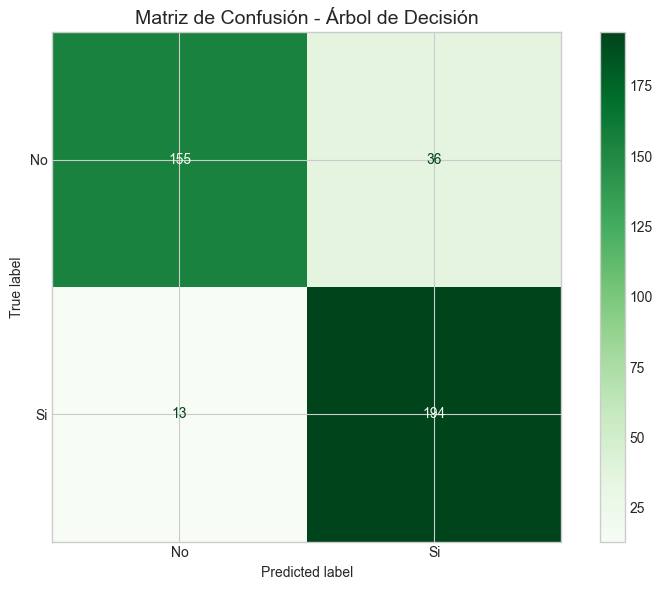


Interpretación:
  - Verdaderos Negativos (TN): 155
  - Falsos Positivos (FP): 36
  - Falsos Negativos (FN): 13 (pacientes con hipertensión no detectados)
  - Verdaderos Positivos (TP): 194


In [153]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))

cm_tree = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['No', 'Si'])
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('Matriz de Confusión - Árbol de Decisión', fontsize=14)

plt.tight_layout()
plt.show()

# Interpretación
tn, fp, fn, tp = cm_tree.ravel()
print(f"\nInterpretación:")
print(f"  - Verdaderos Negativos (TN): {tn}")
print(f"  - Falsos Positivos (FP): {fp}")
print(f"  - Falsos Negativos (FN): {fn} (pacientes con hipertensión no detectados)")
print(f"  - Verdaderos Positivos (TP): {tp}")

In [154]:
# Guardar métricas para comparación
metricas_tree = {
    'Modelo': 'DecisionTree',
    'Accuracy': accuracy_score(y_test, y_pred_tree),
    'Precision': precision_score(y_test, y_pred_tree, pos_label=1),
    'Recall': recall_score(y_test, y_pred_tree, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_tree, pos_label=1)
}

print("=== Resumen de Métricas (Árbol de Decisión) ===")
for metrica, valor in metricas_tree.items():
    if metrica != 'Modelo':
        print(f"  {metrica}: {valor:.4f}")

=== Resumen de Métricas (Árbol de Decisión) ===
  Accuracy: 0.8769
  Precision: 0.8435
  Recall: 0.9372
  F1-Score: 0.8879


---
## 5. Tabla Comparativa de Modelos

Comparación del rendimiento de los mejores modelos obtenidos en las actividades 2 y 3.

In [155]:
# Crear tabla comparativa
tabla_comparativa = pd.DataFrame([metricas_lr_svc, metricas_tree])
tabla_comparativa = tabla_comparativa.set_index('Modelo')

print("=== Tabla Comparativa de Rendimiento en Test ===")
print(tabla_comparativa.round(4).to_string())

=== Tabla Comparativa de Rendimiento en Test ===
              Accuracy  Precision  Recall  F1-Score
Modelo                                             
SVC             0.6256     0.5819  0.9952    0.7344
DecisionTree    0.8769     0.8435  0.9372    0.8879


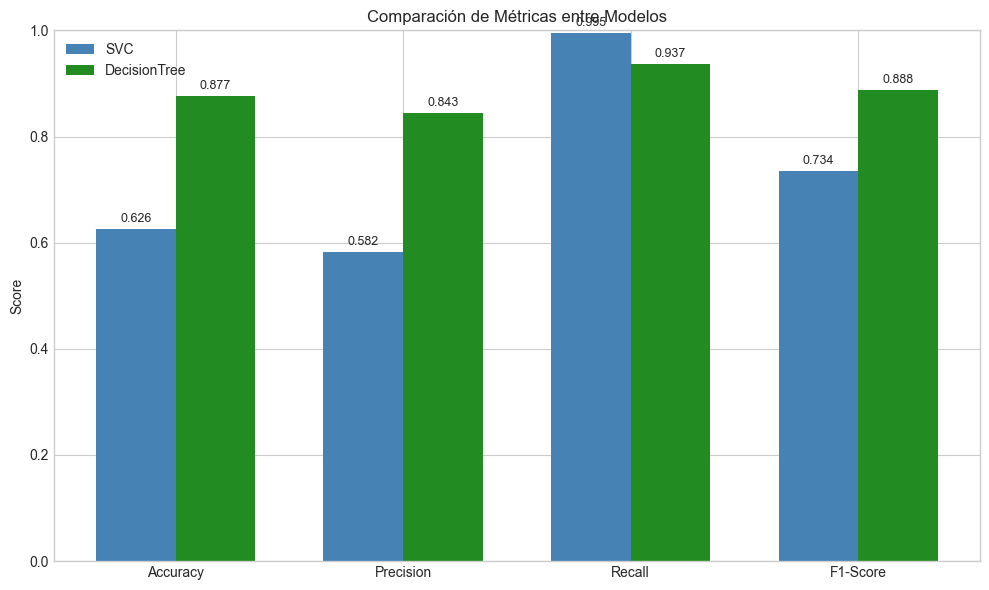

In [156]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(tabla_comparativa.columns))
width = 0.35

bars1 = ax.bar(x - width/2, tabla_comparativa.iloc[0], width, label=tabla_comparativa.index[0], color='steelblue')
bars2 = ax.bar(x + width/2, tabla_comparativa.iloc[1], width, label=tabla_comparativa.index[1], color='forestgreen')

ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas entre Modelos')
ax.set_xticks(x)
ax.set_xticklabels(tabla_comparativa.columns)
ax.legend()
ax.set_ylim(0, 1)

# Añadir valores sobre las barras
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [157]:
# Determinar el mejor modelo según desempeño global
# Métricas: Accuracy, Precision, Recall y F1-Score

# Contar en cuántas métricas gana cada modelo
victorias = {}
for modelo in tabla_comparativa.index:
    victorias[modelo] = sum(tabla_comparativa[col].idxmax() == modelo for col in tabla_comparativa.columns)

print("=== Análisis de Mejor Desempeño Global ===")
for modelo, wins in victorias.items():
    print(f"  {modelo}: gana en {wins}/4 métricas")

# El modelo con mejor desempeño global
mejor_modelo_nombre = max(victorias, key=victorias.get)
print(f"\n✓ El modelo con mejor desempeño global es: {mejor_modelo_nombre}")
print(f"  - Accuracy: {tabla_comparativa.loc[mejor_modelo_nombre, 'Accuracy']:.4f}")
print(f"  - Precision: {tabla_comparativa.loc[mejor_modelo_nombre, 'Precision']:.4f}")
print(f"  - Recall: {tabla_comparativa.loc[mejor_modelo_nombre, 'Recall']:.4f}")
print(f"  - F1-Score: {tabla_comparativa.loc[mejor_modelo_nombre, 'F1-Score']:.4f}")

# Seleccionar el mejor modelo para bootstrapping
if mejor_modelo_nombre == 'DecisionTree':
    mejor_modelo = best_model_tree
    y_pred_mejor = y_pred_tree
else:
    mejor_modelo = best_model_lr_svc
    y_pred_mejor = y_pred_lr_svc

print(f"\nEste modelo será utilizado para el análisis de bootstrapping.")

=== Análisis de Mejor Desempeño Global ===
  SVC: gana en 1/4 métricas
  DecisionTree: gana en 3/4 métricas

✓ El modelo con mejor desempeño global es: DecisionTree
  - Accuracy: 0.8769
  - Precision: 0.8435
  - Recall: 0.9372
  - F1-Score: 0.8879

Este modelo será utilizado para el análisis de bootstrapping.


---
## 6. Bootstrapping para Intervalos de Confianza

### 6.1 ¿Qué es Bootstrapping?

Bootstrapping es una técnica de remuestreo que permite estimar la variabilidad de una estadística sin hacer supuestos sobre la distribución de los datos. El procedimiento es:

1. **Remuestreo con reemplazo:** Crear múltiples muestras del mismo tamaño que el conjunto original, seleccionando observaciones aleatoriamente con reemplazo
2. **Calcular la métrica:** Para cada muestra, calcular la métrica de interés (en nuestro caso, Recall y Precision)
3. **Estimar el intervalo:** Usar los percentiles de la distribución de métricas para construir el intervalo de confianza

**¿Por qué es útil en este contexto?**

Nos permite entender qué tan estable es el rendimiento de nuestro modelo. Un intervalo de confianza estrecho indica que el modelo es consistente, mientras que uno amplio sugiere alta variabilidad.

### 6.2 Implementación del Bootstrapping

In [158]:
def bootstrap_metrics(y_true, y_pred, n_iterations=1000, confidence=0.95, random_state=77):
    """
    Calcula intervalos de confianza para métricas de clasificación usando bootstrapping.
    
    Parámetros:
    -----------
    y_true : array-like
        Valores verdaderos
    y_pred : array-like
        Predicciones del modelo
    n_iterations : int
        Número de iteraciones de bootstrap (default: 1000)
    confidence : float
        Nivel de confianza para el intervalo (default: 0.95)
    random_state : int
        Semilla para reproducibilidad
    
    Retorna:
    --------
    dict : Diccionario con métricas y sus intervalos de confianza
    """
    np.random.seed(random_state)
    
    n_samples = len(y_true)
    
    # Convertir a arrays numpy si son Series
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    
    # Almacenar métricas de cada iteración
    recalls = []
    precisions = []
    f1_scores = []
    accuracies = []
    
    for i in range(n_iterations):
        # Muestreo con reemplazo
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        y_true_boot = y_true_arr[indices]
        y_pred_boot = y_pred_arr[indices]
        
        # Calcular métricas (manejo de casos donde una clase no aparece)
        try:
            recalls.append(recall_score(y_true_boot, y_pred_boot, pos_label= 1, zero_division=0))
            precisions.append(precision_score(y_true_boot, y_pred_boot, pos_label= 1, zero_division=0))
            f1_scores.append(f1_score(y_true_boot, y_pred_boot, pos_label= 1, zero_division=0))
            accuracies.append(accuracy_score(y_true_boot, y_pred_boot))
        except:
            continue
    
    # Calcular percentiles para intervalo de confianza
    alpha = 1 - confidence
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    results = {
        'Recall': {
            'mean': np.mean(recalls),
            'std': np.std(recalls),
            'ci_lower': np.percentile(recalls, lower_percentile),
            'ci_upper': np.percentile(recalls, upper_percentile)
        },
        'Precision': {
            'mean': np.mean(precisions),
            'std': np.std(precisions),
            'ci_lower': np.percentile(precisions, lower_percentile),
            'ci_upper': np.percentile(precisions, upper_percentile)
        },
        'F1-Score': {
            'mean': np.mean(f1_scores),
            'std': np.std(f1_scores),
            'ci_lower': np.percentile(f1_scores, lower_percentile),
            'ci_upper': np.percentile(f1_scores, upper_percentile)
        },
        'Accuracy': {
            'mean': np.mean(accuracies),
            'std': np.std(accuracies),
            'ci_lower': np.percentile(accuracies, lower_percentile),
            'ci_upper': np.percentile(accuracies, upper_percentile)
        }
    }
    
    # Guardar distribuciones para visualización
    results['distributions'] = {
        'recalls': recalls,
        'precisions': precisions,
        'f1_scores': f1_scores,
        'accuracies': accuracies
    }
    
    return results

print("Función de bootstrapping definida.")

Función de bootstrapping definida.


In [159]:
# Ejecutar bootstrapping
print(f"Ejecutando bootstrapping con 1000 iteraciones...")
print(f"Modelo evaluado: {mejor_modelo_nombre}")

bootstrap_results = bootstrap_metrics(
    y_true=y_test,
    y_pred=y_pred_mejor,
    n_iterations=1000,
    confidence=0.95,
    random_state=RANDOM_STATE
)

print("\n✓ Bootstrapping completado.")

Ejecutando bootstrapping con 1000 iteraciones...
Modelo evaluado: DecisionTree

✓ Bootstrapping completado.


### 6.3 Resultados del Bootstrapping

In [160]:
# Mostrar resultados
print("=== Intervalos de Confianza al 95% ===")
print(f"\nModelo: {mejor_modelo_nombre}")
print(f"Basado en 1000 iteraciones de bootstrap\n")

for metric in ['Recall', 'Precision', 'F1-Score', 'Accuracy']:
    data = bootstrap_results[metric]
    print(f"{metric}:")
    print(f"  - Media: {data['mean']:.4f}")
    print(f"  - Desviación estándar: {data['std']:.4f}")
    print(f"  - IC 95%: [{data['ci_lower']:.4f}, {data['ci_upper']:.4f}]")
    print(f"  - Amplitud del IC: {data['ci_upper'] - data['ci_lower']:.4f}")
    print()

=== Intervalos de Confianza al 95% ===

Modelo: DecisionTree
Basado en 1000 iteraciones de bootstrap

Recall:
  - Media: 0.9376
  - Desviación estándar: 0.0171
  - IC 95%: [0.9019, 0.9676]
  - Amplitud del IC: 0.0657

Precision:
  - Media: 0.8444
  - Desviación estándar: 0.0238
  - IC 95%: [0.7959, 0.8894]
  - Amplitud del IC: 0.0935

F1-Score:
  - Media: 0.8883
  - Desviación estándar: 0.0159
  - IC 95%: [0.8557, 0.9177]
  - Amplitud del IC: 0.0620

Accuracy:
  - Media: 0.8776
  - Desviación estándar: 0.0165
  - IC 95%: [0.8442, 0.9095]
  - Amplitud del IC: 0.0653



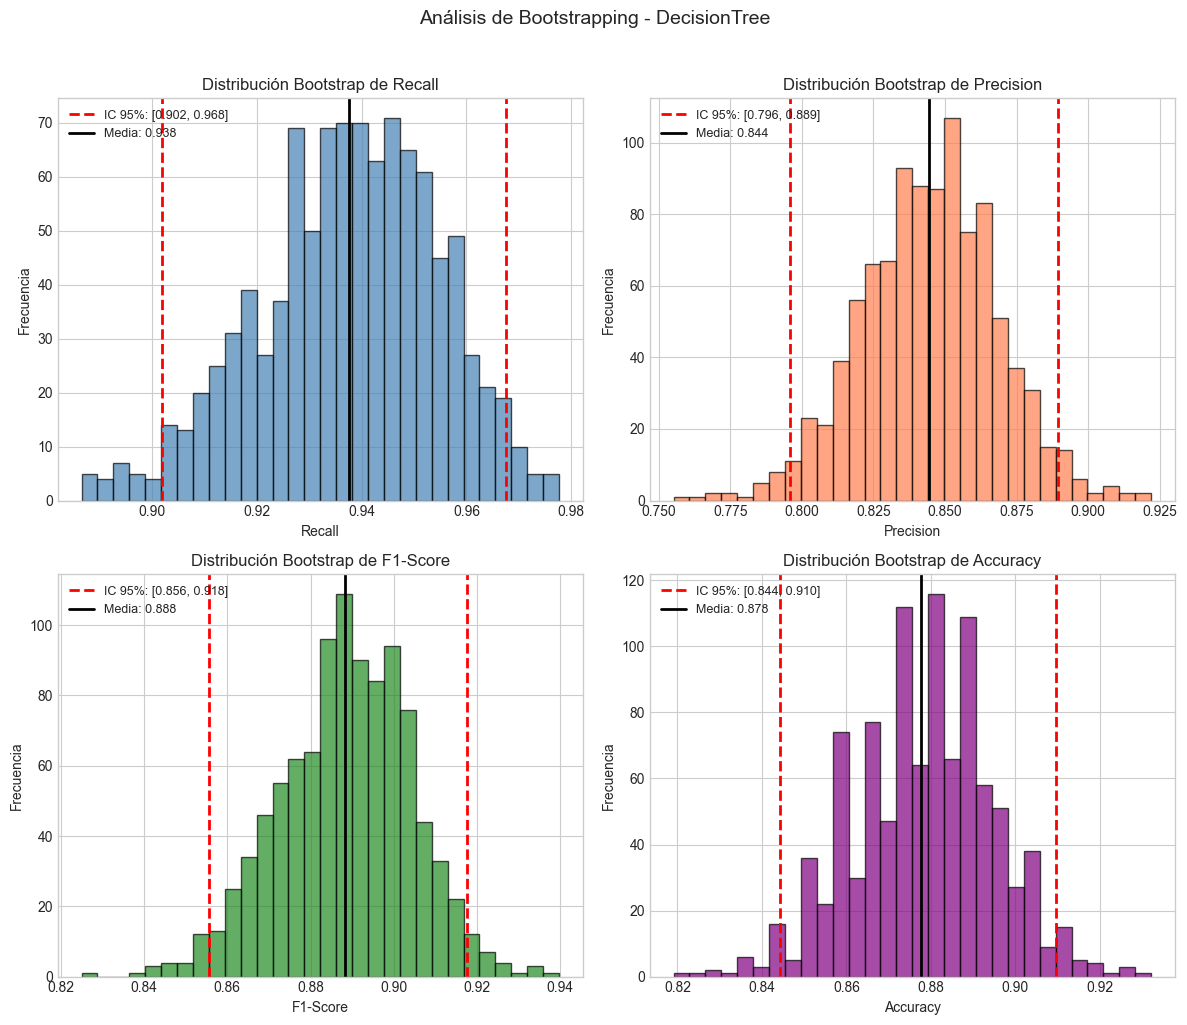

In [161]:
# Visualización de las distribuciones bootstrap
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

metrics_names = ['Recall', 'Precision', 'F1-Score', 'Accuracy']
dist_names = ['recalls', 'precisions', 'f1_scores', 'accuracies']
colors = ['steelblue', 'coral', 'forestgreen', 'purple']

for i, (metric, dist_name, color) in enumerate(zip(metrics_names, dist_names, colors)):
    data = bootstrap_results['distributions'][dist_name]
    ci_lower = bootstrap_results[metric]['ci_lower']
    ci_upper = bootstrap_results[metric]['ci_upper']
    mean_val = bootstrap_results[metric]['mean']
    
    axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7, color=color)
    axes[i].axvline(ci_lower, color='red', linestyle='--', linewidth=2, label=f'IC 95%: [{ci_lower:.3f}, {ci_upper:.3f}]')
    axes[i].axvline(ci_upper, color='red', linestyle='--', linewidth=2)
    axes[i].axvline(mean_val, color='black', linestyle='-', linewidth=2, label=f'Media: {mean_val:.3f}')
    axes[i].set_title(f'Distribución Bootstrap de {metric}', fontsize=12)
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(loc='upper left', fontsize=9)

plt.suptitle(f'Análisis de Bootstrapping - {mejor_modelo_nombre}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Interpretación de los Intervalos de Confianza

**¿Qué nos dicen los intervalos de confianza?**

El intervalo de confianza al 95% nos indica que, si repitiéramos el proceso de evaluación muchas veces con diferentes muestras de la población, el 95% de las veces el valor real de la métrica estaría dentro de ese intervalo.

**Interpretación en el contexto clínico:**

- **Recall:** El intervalo nos indica con qué confianza podemos esperar detectar pacientes con hipertensión. Un intervalo estrecho indica que el modelo es consistente en su capacidad de detección.

- **Precision:** El intervalo nos indica la variabilidad en la proporción de predicciones positivas que son correctas.

**Estabilidad del modelo:**

- Un intervalo de confianza **estrecho** (amplitud < 0.05) indica alta estabilidad y confiabilidad
- Un intervalo de confianza **amplio** (amplitud > 0.10) sugiere que el modelo tiene alta variabilidad y sus predicciones pueden ser menos confiables

## 7. Reglas del Árbol de Decisión (Profundidad 3)

Generar las reglas de decisión utilizando un árbol con profundidad máxima de 3 para interpretabilidad.

In [ ]:
# Entrenar un árbol con profundidad 3 para extraer reglas
# Usar el mismo preprocesador que el mejor árbol

# Preprocesador
preprocessor_rules = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

# Pipeline con árbol de profundidad 3
pipeline_rules = Pipeline(steps=[
    ('preprocessor', preprocessor_rules),
    ('classifier', DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE))
])

# Entrenar
pipeline_rules.fit(X_train, y_train)

print("Árbol de profundidad 3 entrenado para extracción de reglas.")

Árbol de profundidad 3 entrenado para extracción de reglas.


In [163]:
# Obtener nombres de features después del preprocesamiento
# Las numéricas mantienen sus nombres, las categóricas se expanden con OneHot

# Obtener nombres de las columnas categóricas después de OneHot
ohe = pipeline_rules.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_features).tolist()

# Nombres completos de features
feature_names = num_features + cat_feature_names

print(f"Total de features después del preprocesamiento: {len(feature_names)}")
print(f"\nFeatures: {feature_names}")

Total de features después del preprocesamiento: 16

Features: ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI', 'Glucosa', 'Medicación_Diuretico', 'Medicación_InhibidorACE', 'Medicación_Ninguna', 'Medicación_Otro', 'Historia_Familiar_Si', 'Actividad_Fisica_Baja', 'Actividad_Fisica_Moderada', 'Fumador_Si', 'Enfermedad_Corazon_Si']


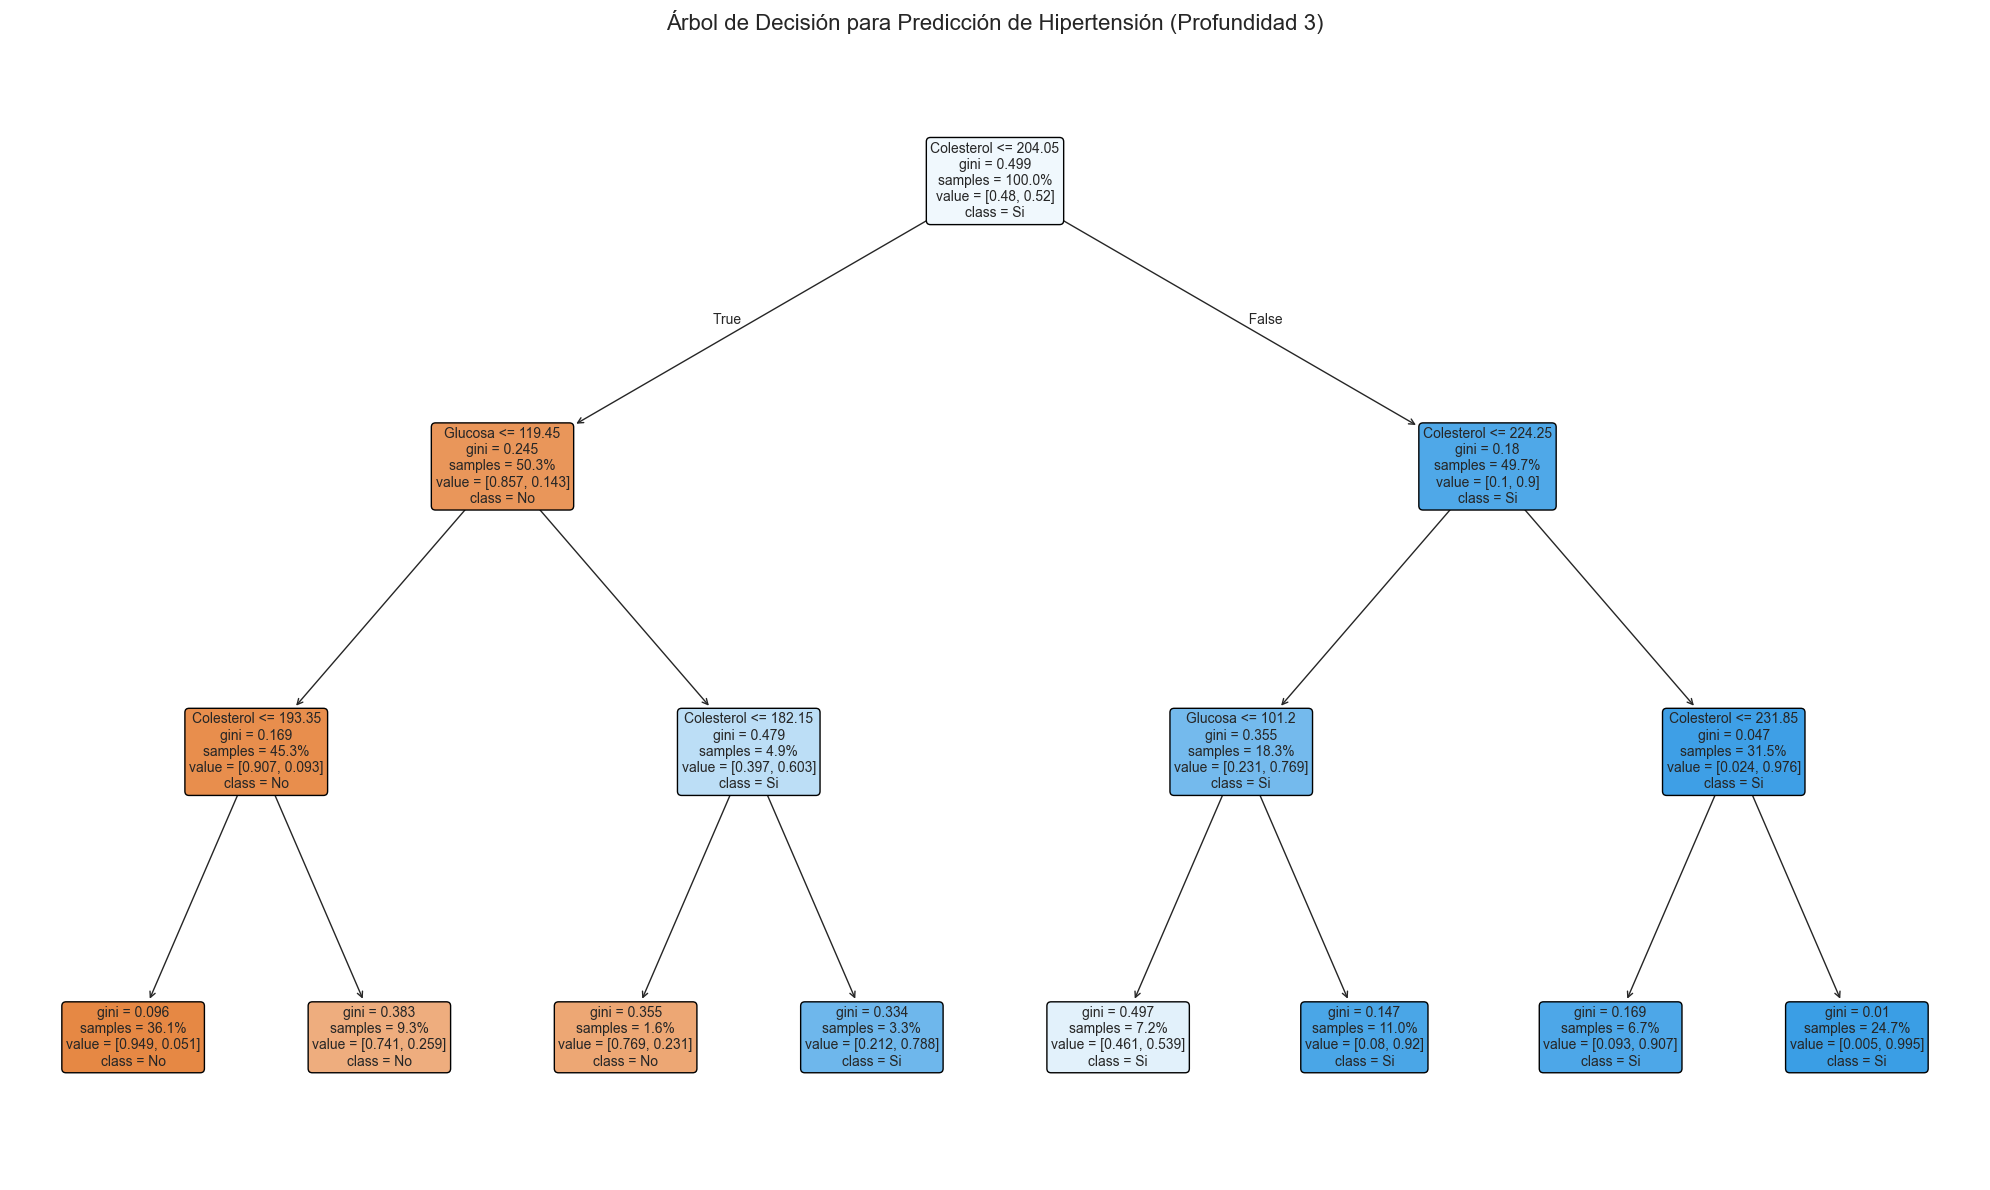

In [164]:
# Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 12))

tree_model = pipeline_rules.named_steps['classifier']

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['No', 'Si'],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=10,
    proportion=True
)

ax.set_title('Árbol de Decisión para Predicción de Hipertensión (Profundidad 3)', fontsize=16)
plt.tight_layout()
plt.show()

In [165]:
# Exportar reglas en formato texto
print("=== Reglas del Árbol de Decisión ===")
print(f"(Profundidad máxima: 3)\n")

rules_text = export_text(
    tree_model,
    feature_names=feature_names,
    class_names=['No', 'Si']
)

print(rules_text)

=== Reglas del Árbol de Decisión ===
(Profundidad máxima: 3)

|--- Colesterol <= 204.05
|   |--- Glucosa <= 119.45
|   |   |--- Colesterol <= 193.35
|   |   |   |--- class: No
|   |   |--- Colesterol >  193.35
|   |   |   |--- class: No
|   |--- Glucosa >  119.45
|   |   |--- Colesterol <= 182.15
|   |   |   |--- class: No
|   |   |--- Colesterol >  182.15
|   |   |   |--- class: Si
|--- Colesterol >  204.05
|   |--- Colesterol <= 224.25
|   |   |--- Glucosa <= 101.20
|   |   |   |--- class: Si
|   |   |--- Glucosa >  101.20
|   |   |   |--- class: Si
|   |--- Colesterol >  224.25
|   |   |--- Colesterol <= 231.85
|   |   |   |--- class: Si
|   |   |--- Colesterol >  231.85
|   |   |   |--- class: Si



### 7.1 Interpretación de las reglas

Las reglas extraídas del árbol de decisión identifican los patrones para determinar cuándo un paciente está en riesgo de sufrir hipertensión.

**Reglas para clasificar como Hipertensión = Sí:**

1. **Colesterol > 204.05** → Prácticamente todos clasificados como **Sí**
   - Si Colesterol > 224.25 → Sí (independiente de Glucosa)
   - Si 204.05 < Colesterol ≤ 224.25 → Sí (independiente de Glucosa)

2. **Colesterol ≤ 204.05 Y Glucosa > 119.45 Y Colesterol > 182.15** → **Sí**
   - Pacientes con colesterol moderado-alto y glucosa elevada

**Reglas para clasificar como Hipertensión = No:**

3. **Colesterol ≤ 204.05 Y Glucosa ≤ 119.45** → **No**
   - Independiente del valor exacto de colesterol en ese rango

4. **Colesterol ≤ 182.15 Y Glucosa > 119.45** → **No**
   - Colesterol bajo compensa la glucosa alta

**Resumen clínico:**

| Condición | Clasificación |
|-----------|---------------|
| Colesterol > 204 mg/dL | Alto riesgo (Sí) |
| Colesterol ≤ 204 Y Glucosa ≤ 119 | Bajo riesgo (No) |
| Colesterol 182-204 Y Glucosa > 119 | Alto riesgo (Sí) |
| Colesterol ≤ 182 Y Glucosa > 119 | Bajo riesgo (No) |

**Utilidad clínica:**

Estas reglas permiten a los profesionales de salud:
1. Identificar rápidamente pacientes de alto riesgo con solo dos mediciones (Colesterol y Glucosa)
2. Priorizar intervenciones en pacientes con Colesterol > 204 mg/dL
3. Considerar evaluación adicional cuando Glucosa > 119 mg/dL en pacientes con colesterol moderado

In [166]:
# Importancia de variables según el árbol
print("=== Importancia de Variables (Árbol Profundidad 3) ===")

importances = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': tree_model.feature_importances_
}).sort_values('Importancia', ascending=False)

# Mostrar solo variables con importancia > 0
importances_relevantes = importances[importances['Importancia'] > 0]
print(importances_relevantes.to_string(index=False))

=== Importancia de Variables (Árbol Profundidad 3) ===
  Variable  Importancia
Colesterol     0.896917
   Glucosa     0.103083


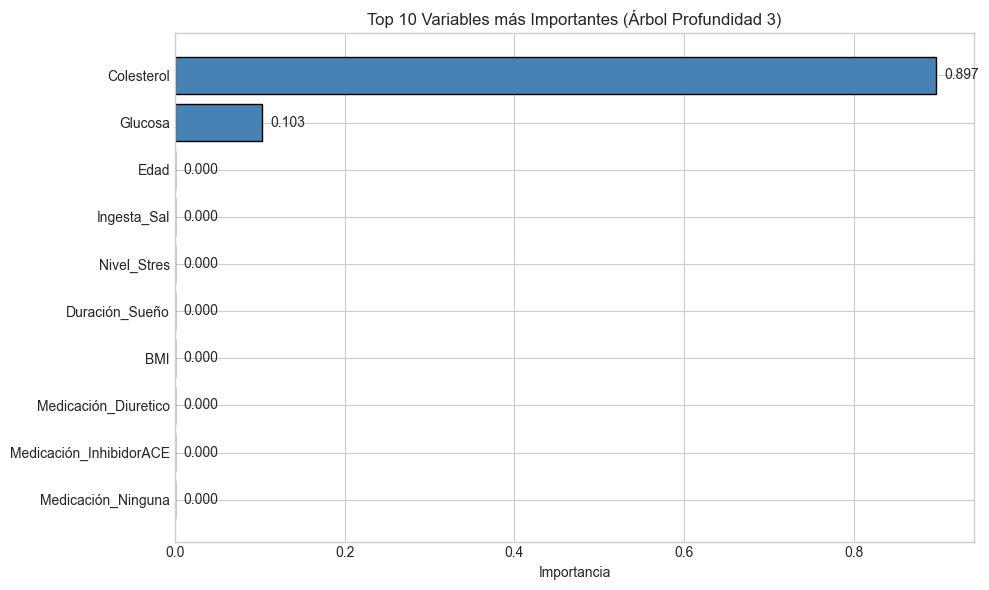

In [167]:
# Visualizar importancia de variables
fig, ax = plt.subplots(figsize=(10, 6))

importances_top = importances.head(10)
bars = ax.barh(importances_top['Variable'], importances_top['Importancia'], color='steelblue', edgecolor='black')
ax.set_xlabel('Importancia')
ax.set_title('Top 10 Variables más Importantes (Árbol Profundidad 3)')
ax.invert_yaxis()

# Añadir valores
for bar, val in zip(bars, importances_top['Importancia']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 8. Análisis de Resultados (Sección E)

En esta sección respondemos las preguntas planteadas en el taller.

### Pregunta 1: ¿Qué puedes decir de los valores de las métricas recall y precisión para cada una de las clases en cada modelo? ¿Cuál de estas métricas consideras que es más importante con base en la descripción del problema?

In [168]:
# Análisis detallado de métricas por clase
print("=== Análisis de Recall y Precision por Clase ===")

print(f"\n--- Modelo: {metricas_lr_svc['Modelo']} ---")
print(classification_report(y_test, y_pred_lr_svc))

print(f"\n--- Modelo: DecisionTree ---")
print(classification_report(y_test, y_pred_tree))

=== Análisis de Recall y Precision por Clase ===

--- Modelo: SVC ---
              precision    recall  f1-score   support

           0       0.98      0.23      0.37       191
           1       0.58      1.00      0.73       207

    accuracy                           0.63       398
   macro avg       0.78      0.61      0.55       398
weighted avg       0.77      0.63      0.56       398


--- Modelo: DecisionTree ---
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       191
           1       0.84      0.94      0.89       207

    accuracy                           0.88       398
   macro avg       0.88      0.87      0.88       398
weighted avg       0.88      0.88      0.88       398



**Respuesta Pregunta 1:**

**Análisis de las métricas obtenidas:**

| Modelo | Clase | Precision | Recall |
|--------|-------|-----------|--------|
| SVC | No (0) | 0.98 | 0.23 |
| SVC | Sí (1) | 0.58 | 1.00 |
| Árbol | No (0) | 0.92 | 0.81 |
| Árbol | Sí (1) | 0.84 | 0.94 |

El SVC tiene Recall perfecto para hipertensos pero sacrifica mucho la Precision (muchos falsos positivos). El Árbol logra mejor equilibrio en ambas métricas.

En cuanto a **cuál métrica es más importante**, definitivamente es el **Recall** para la clase "Sí" (hipertensos) porque:

1. **Consecuencias de los errores:**
   - Falso Negativo (bajo Recall): No detectar a un paciente hipertenso puede llevar a complicaciones graves como infartos o accidentes cerebrovasculares
   - Falso Positivo (baja Precision): Clasificar erróneamente a un paciente sano genera exámenes adicionales, pero no pone en riesgo su vida

2. **Contexto de medicina preventiva:** El objetivo es detectar la mayor cantidad posible de casos para intervención temprana

3. **Costo-beneficio:** El costo de tratar erróneamente es mucho menor que el de no tratar

### Pregunta 2: ¿Consideras que el rendimiento de los modelos es adecuado? Si no es así, ¿cómo podrían mejorarse los resultados?

In [169]:
# Resumen de rendimiento
print("=== Resumen de Rendimiento ===")
print(tabla_comparativa.round(4))

=== Resumen de Rendimiento ===
              Accuracy  Precision  Recall  F1-Score
Modelo                                             
SVC             0.6256     0.5819  0.9952    0.7344
DecisionTree    0.8769     0.8435  0.9372    0.8879


**Respuesta Pregunta 2:**

**Evaluación del rendimiento:**

El **Árbol de Decisión tiene rendimiento adecuado** (Accuracy: 87.7%, Recall: 93.7%, F1: 88.8%).

El **SVC tiene rendimiento problemático**: aunque detecta el 99.5% de hipertensos, su Accuracy de 62.6% y Precision de 58% indican que clasifica erróneamente a muchos pacientes sanos como enfermos.

**Posibles mejoras:**

1. **Ingeniería de características:**
   - Crear interacciones entre variables (ej: BMI × Edad)
   - Binning de variables continuas (grupos de edad, categorías de BMI)
   - Ratios clínicos relevantes

2. **Modelos más complejos:**
   - Random Forest (ensemble de árboles)
   - Gradient Boosting (XGBoost, LightGBM)
   - Redes neuronales

3. **Ajuste de umbral de decisión:**
   - Mover el umbral de clasificación para aumentar Recall a costa de Precision

4. **Más datos:**
   - Aumentar el tamaño del dataset
   - Incluir más variables clínicas (presión arterial histórica, medicamentos, etc.)

5. **Técnicas de balanceo:**
   - Aunque las clases están balanceadas, se podría probar SMOTE o class_weight

### Pregunta 3: ¿Cuáles son las variables más significativas según el mejor modelo basado en árboles de decisión?

In [170]:
# Importancia de variables del mejor árbol
print("=== Variables más Significativas (Mejor Árbol) ===")

tree_best = best_model_tree.named_steps['classifier']

# Obtener nombres de features del mejor árbol
ohe_best = best_model_tree.named_steps['preprocessor'].named_transformers_['cat']
cat_names_best = ohe_best.get_feature_names_out(cat_features).tolist()
feature_names_best = num_features + cat_names_best

importances_best = pd.DataFrame({
    'Variable': feature_names_best,
    'Importancia': tree_best.feature_importances_
}).sort_values('Importancia', ascending=False)

print(importances_best[importances_best['Importancia'] > 0].to_string(index=False))

=== Variables más Significativas (Mejor Árbol) ===
  Variable  Importancia
Colesterol     0.868632
   Glucosa     0.131368


**Respuesta Pregunta 3:**

**Variables más significativas (Mejor Árbol):**
1. **Colesterol**: 86.9% de importancia
2. **Glucosa**: 13.1% de importancia

Estas dos variables concentran el 100% de la importancia dentro del modelo de árbol ajustado.

**Reflexión sobre el impacto en decisiones clínicas:**

Este conocimiento puede ayudar a:

1. **Priorizar evaluaciones:** Enfocarse en pacientes con valores altos en las variables más importantes
2. **Intervenciones preventivas:** Diseñar programas de prevención enfocados en los factores de riesgo modificables identificados
3. **Educación al paciente:** Comunicar de manera clara qué factores tienen mayor influencia
4. **Optimización de recursos:** Dirigir recursos de salud pública hacia los factores más influyentes

### Pregunta 4: Si ambos modelos presentan resultados similares en las métricas de desempeño, ¿cuál seleccionarías considerando el contexto clínico del problema?

**Respuesta Pregunta 4:**

Los modelos **NO** presentan resultados similares:

| Métrica | SVC | Árbol |
|---------|-----|-------|
| Accuracy | 62.6% | **87.7%** |
| Precision | 58.2% | **84.4%** |
| Recall | **99.5%** | 93.7% |
| F1-Score | 73.4% | **88.8%** |

El Árbol domina en 3 de 4 métricas. Por lo tanto, se selecciona como mejor modelo no solo por interpretabilidad, sino también por mejor desempeño global.

**Respondiendo a la pregunta hipotética:**

Si los modelos tuvieran rendimiento similar, seleccionaría el **Árbol de Decisión** por las siguientes razones:

1. **Interpretabilidad:**
   - Los árboles generan reglas que los médicos pueden entender y explicar a los pacientes
   - La Regresión Logística ofrece coeficientes, pero su interpretación es menos intuitiva
   - SVC con kernel RBF es prácticamente una "caja negra"

2. **Transparencia en medicina:**
   - Los profesionales de salud necesitan justificar sus decisiones
   - Las reglas del árbol permiten explicar por qué un paciente es clasificado como de riesgo

3. **Cumplimiento regulatorio:**
   - En contextos médicos, la explicabilidad del modelo puede ser requerida por regulaciones

4. **Confianza del usuario:**
   - Tanto médicos como pacientes confían más en decisiones que pueden entender

**Conclusión:** En nuestro análisis, el Árbol de Decisión es la mejor opción tanto por su superior desempeño global como por su interpretabilidad clínica.

### Pregunta 5: ¿Qué indica el intervalo de confianza estimado sobre la estabilidad y confiabilidad del modelo seleccionado?

In [171]:
# Resumen de intervalos de confianza
print("=== Intervalos de Confianza del Mejor Modelo ===")
print(f"\nModelo: {mejor_modelo_nombre}")

for metric in ['Recall', 'Precision']:
    data = bootstrap_results[metric]
    amplitud = data['ci_upper'] - data['ci_lower']
    print(f"\n{metric}:")
    print(f"  - IC 95%: [{data['ci_lower']:.4f}, {data['ci_upper']:.4f}]")
    print(f"  - Amplitud: {amplitud:.4f}")
    if amplitud < 0.05:
        print(f"  - Interpretación: Alta estabilidad ✓")
    elif amplitud < 0.10:
        print(f"  - Interpretación: Estabilidad moderada")
    else:
        print(f"  - Interpretación: Baja estabilidad - considerar más datos")

=== Intervalos de Confianza del Mejor Modelo ===

Modelo: DecisionTree

Recall:
  - IC 95%: [0.9019, 0.9676]
  - Amplitud: 0.0657
  - Interpretación: Estabilidad moderada

Precision:
  - IC 95%: [0.7959, 0.8894]
  - Amplitud: 0.0935
  - Interpretación: Estabilidad moderada


**Respuesta Pregunta 5:**

**Intervalos de Confianza del Árbol de Decisión (IC 95%):**

| Métrica | IC 95% | Amplitud | Interpretación |
|---------|--------|----------|----------------|
| Recall | [0.9019, 0.9676] | 0.0657 | Estabilidad moderada |
| Precision | [0.7959, 0.8894] | 0.0935 | Estabilidad moderada |

**Interpretación en el contexto clínico:**

El intervalo de Recall [0.9019, 0.9676] indica que, con un 95% de confianza, podemos esperar que el modelo detecte entre el 90.2% y 96.8% de los pacientes con hipertensión. Este rango es clínicamente aceptable para una herramienta de screening.

**Análisis de estabilidad:**

- Ambas métricas tienen amplitud entre 0.05 y 0.10, lo que indica **estabilidad moderada**
- El modelo produce resultados consistentes a través de diferentes muestras
- La variabilidad observada es aceptable para un modelo de apoyo al diagnóstico

**Implicaciones para la práctica clínica:**

1. El modelo es suficientemente estable para uso como herramienta de screening inicial
2. Los profesionales de salud pueden confiar en que el rendimiento será consistente
3. Se recomienda complementar con evaluación clínica directa dado que ningún modelo es perfecto

---
## 9. Conclusiones

**Resumen del análisis:**

1. Se realizó un análisis exploratorio completo identificando problemas de calidad de datos (4 duplicados y 3 valores anómalos en Colesterol) que fueron corregidos.

2. Se construyeron dos pipelines de clasificación:
   - Pipeline 1: Regresión Logística y SVC con búsqueda de escaladores, encoders y valor de C
   - Pipeline 2: Árbol de Decisión con exploración de profundidad, criterio y parámetros de poda

3. La optimización de hiperparámetros se enfocó en **Recall** durante el GridSearchCV, dado el contexto clínico.

4. **Selección del mejor modelo:** Se seleccionó el **Árbol de Decisión** como mejor modelo global, ya que domina en 3 de 4 métricas evaluadas.

**Comparación final de modelos:**

| Métrica | SVC | Árbol (Seleccionado) |
|---------|-----|----------------------|
| Accuracy | 62.6% | **87.7%** |
| Precision | 58.2% | **84.4%** |
| Recall | **99.5%** | 93.7% |
| F1-Score | 73.4% | **88.8%** |

5. **Estabilidad del modelo:** Los intervalos de confianza mediante bootstrapping muestran que el Árbol de Decisión tiene estabilidad moderada en todas las métricas (Recall IC 95%: [0.90, 0.97]).

6. Se extrajeron reglas interpretables del árbol con profundidad 3.

**Factores más importantes identificados:**

- **Colesterol** (89.7%): Principal predictor de hipertensión según el árbol
- **Glucosa** (10.3%): Segundo factor más relevante

Ambos son factores de riesgo cardiovascular conocidos y modificables, lo que permite diseñar intervenciones preventivas efectivas.

**Recomendaciones:**

- El Árbol de Decisión ofrece el mejor balance entre capacidad predictiva (87.7% accuracy, 93.7% recall) e interpretabilidad
- El modelo puede servir como herramienta de apoyo para screening inicial
- No debe reemplazar el juicio clínico ni las mediciones directas de presión arterial
- Se recomienda monitorear el rendimiento del modelo en producción y reentrenarlo periódicamente